# 03 · Weekly Modelling Table

In this notebook I build **one weekly table** for the modelling team from the cleaned files made in `02_data_processing.ipynb`.

```
week_start | region | y_class (week t+1) | y_cellcount_max | n_habsos_samples
| nutrient features | rain / air-temp features (rolling) | chl_median, chl_anomaly
| wind | water temp | has_mote | has_ksrq | has_nutrients | ... | split
```

Rules:
- **Weekly grain**, weeks start on Monday. Modelling window **2019–2025**. One region for now: the whole Sarasota box.
- **No leakage:** every feature describes week *t* or earlier. The label `y_class` is the class of week *t+1*.
- **"No sample" is not "no bloom":** if week *t+1* has no HABSOS sample, `y_class` is NaN.
- **Split by time**, never randomly: train 2019–2021, validate 2024, test 2025. 2022–2023 are excluded (almost no HABSOS samples).

Outputs: `processed/model_table_weekly.parquet` and `docs/data_dictionary.md`.

## Setup

In [1]:
# Libraries used in this notebook
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Mount Google Drive so we can read the cleaned files
from google.colab import drive
drive.mount('/content/drive')

DATA = '/content/drive/MyDrive/biointerphase_data'
PROCESSED = os.path.join(DATA, 'processed')
DOCS = os.path.join(DATA, 'docs')
os.makedirs(DOCS, exist_ok=True)

print(os.listdir(PROCESSED))

Mounted at /content/drive
['habsos_clean.parquet', 'nutrients_long_clean.parquet', 'nutrients_clean.parquet', 'bradenton_clean.parquet', 'ksrq_clean.parquet', 'wind_grid_clean.parquet', 'mote_clean.parquet', 'chlorophyll_clean.parquet', 'cyanotoxins_clean.parquet']


In [3]:
def add_week_start(df):
    """Add a 'week_start' column: the Monday of the week that holds each date."""
    df['week_start'] = df['date'] - pd.to_timedelta(df['date'].dt.dayofweek, unit='D')
    return df


def assign_split(year):
    """Time-based split: train 2019-2021, validate 2024, test 2025."""
    if year <= 2021:
        return 'train'
    elif year == 2024:
        return 'validate'
    elif year == 2025:
        return 'test'
    else:
        return 'excluded'   # 2022-2023: almost no HABSOS samples

In [4]:
# Load the cleaned sources and add the week to each of them
habsos = add_week_start(pd.read_parquet(os.path.join(PROCESSED, 'habsos_clean.parquet')))
nutr = add_week_start(pd.read_parquet(os.path.join(PROCESSED, 'nutrients_clean.parquet')))
brad = add_week_start(pd.read_parquet(os.path.join(PROCESSED, 'bradenton_clean.parquet')))
ksrq = add_week_start(pd.read_parquet(os.path.join(PROCESSED, 'ksrq_clean.parquet')))
wind = add_week_start(pd.read_parquet(os.path.join(PROCESSED, 'wind_grid_clean.parquet')))
mote = add_week_start(pd.read_parquet(os.path.join(PROCESSED, 'mote_clean.parquet')))
chl = add_week_start(pd.read_parquet(os.path.join(PROCESSED, 'chlorophyll_clean.parquet')))
cyano = add_week_start(pd.read_parquet(os.path.join(PROCESSED, 'cyanotoxins_clean.parquet')))

In [5]:
# Every week of the modelling window (2018-12-31 is the Monday of the week that holds 2019-01-01)
table = pd.DataFrame({'week_start': pd.date_range('2018-12-31', '2025-12-29', freq='W-MON')})
table['region'] = 'sarasota_box'

print('Weeks:', len(table))

Weeks: 366


---
## Weekly features from each source

### HABSOS (target)
Per week: the **max class observed**, the max cell count, and the number of samples.

In [6]:
hab_weekly = habsos.groupby('week_start').agg(
    hab_class=('hab_class', 'max'),
    hab_cellcount_max=('CELLCOUNT', 'max'),
    n_habsos_samples=('CELLCOUNT', 'size'),
).reset_index()

hab_weekly.tail()

,week_start,hab_class,hab_cellcount_max,n_habsos_samples
2689,2026-04-06,0.0,0.0,49
2690,2026-04-13,0.0,0.0,82
2691,2026-04-20,0.0,0.0,53
2692,2026-04-27,0.0,0.0,64
2693,2026-05-04,0.0,333.0,52


### Nutrients
Average of all stations per week (no station coordinates yet, so region level). Nutrients are sampled about once a month, so the last value is carried forward for up to 4 weeks. `has_nutrients` = 1 only in weeks with a real sample.

In [7]:
nutr_cols = [col for col in nutr.columns if col not in ['station_id', 'date', 'week_start']]

nutr_weekly = nutr.groupby('week_start')[nutr_cols].mean()
nutr_weekly = nutr_weekly.add_prefix('nutr_').reset_index()
nutr_weekly['has_nutrients'] = 1

nutr_weekly.tail()

,week_start,nutr_chla_corr_ugL,nutr_cond_umho,nutr_do_mgL,nutr_do_sat_pct,nutr_nh3_mgL,nutr_nox_mgL,nutr_ph,nutr_po4_mgL,nutr_tkn_mgL,nutr_tn_mgL,nutr_tp_mgL,nutr_tss_mgL,nutr_turbidity_ntu,nutr_water_temp_c,has_nutrients
875,2025-11-24,48.474000,802.018000,5.234000,69.072000,0.180400,0.131600,7.212000,0.301400,1.807800,1.939400,0.464600,28.240000,NaN,NaN,1
876,2025-12-01,13.460000,47704.384783,6.704783,93.186522,0.046833,0.011167,7.795217,0.056583,1.030833,1.042000,0.106833,13.466667,NaN,22.065,1
877,2025-12-08,27.529130,3819.373913,6.096522,69.470435,0.121636,0.150609,7.527826,0.292370,1.312348,1.462957,0.408652,18.827273,NaN,NaN,1
878,2025-12-22,10.556773,9183.616364,5.422273,63.066818,0.133381,0.101333,7.549545,0.121386,0.816727,0.913818,0.201500,20.227273,NaN,NaN,1
879,2025-12-29,60.406000,NaN,NaN,NaN,0.312200,0.158400,NaN,0.266400,2.584400,2.742800,0.468800,46.920000,NaN,NaN,1


### Bradenton rain and air temperature

In [8]:
brad_weekly = brad.groupby('week_start').agg(
    rain_total_mm=('rain_mm', 'sum'),
    air_tmax_c=('air_tmax_c', 'max'),
    air_tmin_c=('air_tmin_c', 'min'),
    air_tmean_c=('air_tmean_c', 'mean'),
).reset_index()

brad_weekly.tail()

,week_start,rain_total_mm,air_tmax_c,air_tmin_c,air_tmean_c
570,2025-12-01,46.736,28.888889,13.333333,22.341270
571,2025-12-08,0.508,27.222222,7.222222,17.976190
572,2025-12-15,0.000,26.666667,9.444444,18.888889
573,2025-12-22,0.000,26.666667,11.666667,19.642857
574,2025-12-29,0.762,25.555556,4.444444,15.277778


### KSRQ station, gridded wind and Mote water temperature

In [9]:
# KSRQ: weekly mean of the daily values
ksrq_cols = [col for col in ksrq.columns if col.startswith('ksrq_')]
ksrq_weekly = ksrq.groupby('week_start')[ksrq_cols].mean().reset_index()
ksrq_weekly['has_ksrq'] = 1

# Gridded wind: weekly mean of the offshore u component
wind_weekly = wind.groupby('week_start')['uwnd_offshore'].mean().reset_index()

# Mote: weekly mean and max water temperature
mote_weekly = mote.groupby('week_start').agg(
    mote_temp_mean_c=('mote_temp_mean_c', 'mean'),
    mote_temp_max_c=('mote_temp_max_c', 'max'),
).reset_index()
mote_weekly['has_mote'] = 1

print(len(ksrq_weekly), len(wind_weekly), len(mote_weekly))

206 403 191


### Satellite chlorophyll
Weekly median of the daily medians, plus the **anomaly**: this week's coastal median minus the usual value for the same week of the year. The "usual value" is computed from **2018–2021 only** (the training years), so the test years don't leak into it.

In [10]:
chl_weekly = chl.groupby('week_start')[['chl_box_median', 'chl_coastal_median']].median().reset_index()

# Typical coastal chlorophyll for each week of the year, from the training years only
chl_weekly['week_of_year'] = chl_weekly['week_start'].dt.isocalendar().week.astype(int)
train_years = chl_weekly[chl_weekly['week_start'] < '2022-01-01']
climatology = train_years.groupby('week_of_year')['chl_coastal_median'].median()

chl_weekly['chl_coastal_anomaly'] = chl_weekly['chl_coastal_median'] - chl_weekly['week_of_year'].map(climatology)
chl_weekly = chl_weekly.drop(columns='week_of_year')

chl_weekly.tail()

,week_start,chl_box_median,chl_coastal_median,chl_coastal_anomaly
449,2026-08-10,0.502433,8.063239,0.870290
450,2026-08-17,0.409919,8.448814,1.062181
451,2026-08-24,0.475375,7.797837,1.131296
452,2026-08-31,0.557367,7.107503,-0.243029
453,2026-09-07,0.484470,7.369792,-0.478376


### Cyanotoxins (optional)
Number of samples and number of detections in the box per week (NaN when nothing was sampled).

In [11]:
cyano_weekly = cyano.groupby('week_start').agg(
    cyano_samples=('detected', 'size'),
    cyano_detections=('detected', 'sum'),
).reset_index()

cyano_weekly.tail()

,week_start,cyano_samples,cyano_detections
161,2024-05-20,80,0
162,2024-05-27,32,0
163,2024-06-10,16,0
164,2024-06-24,16,0
165,2024-07-22,48,0


---
## Join everything on `week_start`

In [12]:
for part in [hab_weekly, nutr_weekly, brad_weekly, ksrq_weekly, wind_weekly, mote_weekly, chl_weekly, cyano_weekly]:
    table = table.merge(part, on='week_start', how='left')

# Availability flags: 0 when the source has no data that week
for flag in ['has_nutrients', 'has_ksrq', 'has_mote']:
    table[flag] = table[flag].fillna(0).astype(int)

# Nutrients: carry the last sample forward for up to 4 weeks
nutr_feature_cols = [col for col in table.columns if col.startswith('nutr_')]
table[nutr_feature_cols] = table[nutr_feature_cols].ffill(limit=4)

# Rolling rain over the last 2, 4 and 8 weeks (current week included, no future weeks)
table['rain_2wk_mm'] = table['rain_total_mm'].rolling(2).sum()
table['rain_4wk_mm'] = table['rain_total_mm'].rolling(4).sum()
table['rain_8wk_mm'] = table['rain_total_mm'].rolling(8).sum()

print('Shape:', table.shape)

Shape: (366, 43)


---
## Label, coverage flag and split

- `y_class` and `y_cellcount_max` = next week's values (`shift(-1)`), so features at week *t* predict week *t+1*.
- `hab_class` (this week's class) stays as a feature, because it is known at week *t*.
- `low_coverage` = 1 for 2022–2023.

In [13]:
# Label = next week's class (NaN if next week had no HABSOS sample)
table['y_class'] = table['hab_class'].shift(-1)
table['y_cellcount_max'] = table['hab_cellcount_max'].shift(-1)

# HABSOS almost empty in 2022-2023
table['low_coverage'] = table['week_start'].dt.year.isin([2022, 2023]).astype(int)

# Time-based split
table['split'] = table['week_start'].dt.year.apply(assign_split)

# Put the key and label columns first
first_cols = ['week_start', 'region', 'split', 'y_class', 'y_cellcount_max', 'n_habsos_samples', 'low_coverage']
table = table[first_cols + [col for col in table.columns if col not in first_cols]]

table.head()

,week_start,region,split,y_class,y_cellcount_max,n_habsos_samples,low_coverage,hab_class,hab_cellcount_max,nutr_chla_corr_ugL,...,mote_temp_max_c,has_mote,chl_box_median,chl_coastal_median,chl_coastal_anomaly,cyano_samples,cyano_detections,rain_2wk_mm,rain_4wk_mm,rain_8wk_mm
0,2018-12-31,sarasota_box,train,2.0,1303204.0,73.0,0,2.0,186266667.0,NaN,...,NaN,0,0.687255,6.330664,0.061709,8.0,0.0,NaN,NaN,NaN
1,2019-01-07,sarasota_box,train,2.0,2428000.0,107.0,0,2.0,1303204.0,NaN,...,NaN,0,0.785405,6.225243,0.550108,8.0,2.0,15.748,NaN,NaN
2,2019-01-14,sarasota_box,train,2.0,282720.0,93.0,0,2.0,2428000.0,NaN,...,NaN,0,0.746753,5.929194,0.264531,NaN,NaN,1.524,NaN,NaN
3,2019-01-21,sarasota_box,train,0.0,667.0,76.0,0,2.0,282720.0,NaN,...,NaN,0,0.869726,6.499056,0.539973,NaN,NaN,57.658,73.406,NaN
4,2019-01-28,sarasota_box,train,0.0,333.0,106.0,0,0.0,667.0,NaN,...,NaN,0,0.982401,4.829902,-0.594875,NaN,NaN,56.642,58.166,NaN


In [14]:
# Labelled weeks per split and class
pd.crosstab(table['split'], table['y_class'], margins=True)

y_class,0.0,1.0,2.0,All
split,,,,
excluded,51,2,6,59
test,44,2,5,51
train,91,9,41,141
validate,36,3,13,52
All,222,16,65,303


In [15]:
# Share of missing values per column
(table.isna().mean() * 100).round(1).sort_values(ascending=False)

,0
nutr_turbidity_ntu,97.3
cyano_detections,60.4
cyano_samples,60.4
ksrq_pressure_hpa,50.3
ksrq_dew_point_c,50.3
ksrq_wind_speed,50.3
ksrq_wind_u,50.3
ksrq_air_temp_c,50.3
ksrq_wind_v,50.3
mote_temp_mean_c,47.8


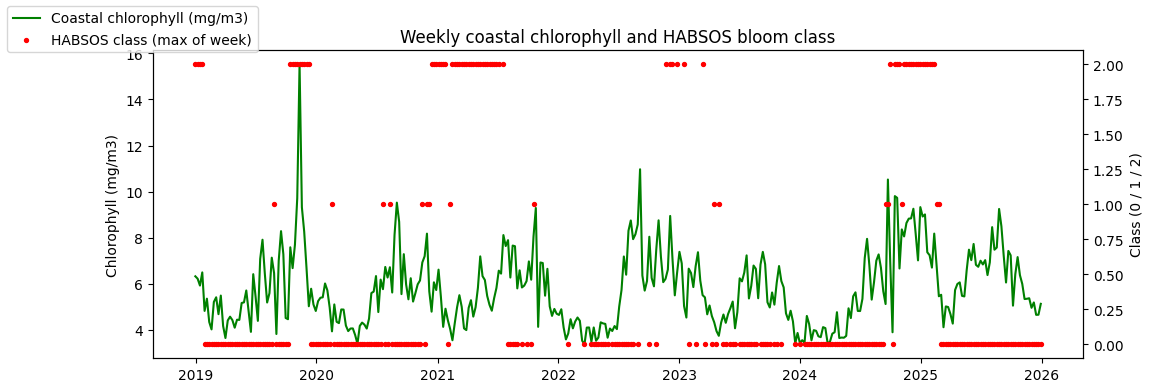

In [16]:
# Quick check: bloom class vs coastal chlorophyll over time
fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(table['week_start'], table['chl_coastal_median'], color='green', label='Coastal chlorophyll (mg/m3)')
ax1.set_ylabel('Chlorophyll (mg/m3)')

ax2 = ax1.twinx()
ax2.scatter(table['week_start'], table['hab_class'], s=8, color='red', label='HABSOS class (max of week)')
ax2.set_ylabel('Class (0 / 1 / 2)')

ax1.set_title('Weekly coastal chlorophyll and HABSOS bloom class')
fig.legend(loc='upper left')
plt.show()

In [17]:
table.to_parquet(os.path.join(PROCESSED, 'model_table_weekly.parquet'), index=False)
print('Saved model_table_weekly.parquet:', table.shape)

Saved model_table_weekly.parquet: (366, 47)


---
## Data dictionary

Every column of the modelling table with its unit, source and how it was made. Saved to `docs/data_dictionary.md`.

In [18]:
dictionary = pd.DataFrame([
    ('week_start', 'date', '-', 'Monday that starts the week (local date, America/New_York)'),
    ('region', '-', '-', 'Study region; for now the whole Sarasota box (lat 26.5-28, lon -83.5 to -81.8)'),
    ('split', '-', '-', 'train (2019-2021), validate (2024), test (2025), excluded (2022-2023)'),
    ('y_class', 'class', 'HABSOS', 'LABEL: max class of week t+1 (0 < 10k, 1 = 10k-99,999, 2 >= 100k cells/L); NaN if no sample'),
    ('y_cellcount_max', 'cells/L', 'HABSOS', 'Max K. brevis cell count of week t+1'),
    ('n_habsos_samples', 'count', 'HABSOS', 'Number of surface samples in the box in week t'),
    ('low_coverage', '0/1', 'HABSOS', '1 for 2022-2023, when HABSOS is almost empty'),
    ('hab_class', 'class', 'HABSOS', 'Max class observed in week t'),
    ('hab_cellcount_max', 'cells/L', 'HABSOS', 'Max cell count in week t'),
    ('nutr_chla_corr_ugL', 'ug/L', 'Water Atlas', 'Chlorophyll-a corrected for pheophytin; mean of stations, last value carried up to 4 weeks'),
    ('nutr_cond_umho', 'umho/cm', 'Water Atlas', 'Specific conductance; same weekly method'),
    ('nutr_do_mgL', 'mg/L', 'Water Atlas', 'Dissolved oxygen (> 25 set to NaN); same weekly method'),
    ('nutr_do_sat_pct', '%', 'Water Atlas', 'Dissolved oxygen saturation; same weekly method'),
    ('nutr_nh3_mgL', 'mg/L', 'Water Atlas', 'Ammonia as N (x1000 unit errors fixed); same weekly method'),
    ('nutr_nox_mgL', 'mg/L', 'Water Atlas', 'Nitrite + nitrate as N; same weekly method'),
    ('nutr_ph', 'pH units', 'Water Atlas', 'pH (outside 0-14 set to NaN); same weekly method'),
    ('nutr_po4_mgL', 'mg/L', 'Water Atlas', 'Phosphate as P; same weekly method'),
    ('nutr_tkn_mgL', 'mg/L', 'Water Atlas', 'Total Kjeldahl nitrogen; same weekly method'),
    ('nutr_tn_mgL', 'mg/L', 'Water Atlas', 'Total nitrogen; same weekly method'),
    ('nutr_tp_mgL', 'mg/L', 'Water Atlas', 'Total phosphorus as P; same weekly method'),
    ('nutr_tss_mgL', 'mg/L', 'Water Atlas', 'Total suspended solids; same weekly method'),
    ('nutr_turbidity_ntu', 'NTU', 'Water Atlas', 'Turbidity; same weekly method'),
    ('nutr_water_temp_c', 'deg C', 'Water Atlas', 'Water temperature (> 100 F set to NaN, converted to C); same weekly method'),
    ('has_nutrients', '0/1', 'Water Atlas', '1 if at least one nutrient sample in week t'),
    ('rain_total_mm', 'mm', 'Bradenton COOP', 'Total rain in week t (inches converted to mm)'),
    ('air_tmax_c', 'deg C', 'Bradenton COOP', 'Max daily max air temperature in week t'),
    ('air_tmin_c', 'deg C', 'Bradenton COOP', 'Min daily min air temperature in week t'),
    ('air_tmean_c', 'deg C', 'Bradenton COOP', 'Mean of daily (max + min) / 2 in week t'),
    ('ksrq_pressure_hpa', 'hPa', 'KSRQ', 'Mean sea-level pressure, weekly mean of daily means'),
    ('ksrq_air_temp_c', 'deg C', 'KSRQ', 'Air temperature (outside -10 to 45 set to NaN), weekly mean'),
    ('ksrq_dew_point_c', 'deg C', 'KSRQ', 'Dew point, weekly mean'),
    ('ksrq_wind_speed', 'm/s', 'KSRQ', 'Wind speed, weekly mean'),
    ('ksrq_wind_u', 'm/s', 'KSRQ', 'East-west wind component (from speed and direction), weekly mean'),
    ('ksrq_wind_v', 'm/s', 'KSRQ', 'North-south wind component, weekly mean'),
    ('has_ksrq', '0/1', 'KSRQ', '1 if KSRQ has data in week t (starts July 2022)'),
    ('uwnd_offshore', 'm/s', 'Gridded wind', 'East-west wind over the offshore grid cells, weekly mean (vwnd not available yet)'),
    ('mote_temp_mean_c', 'deg C', 'Mote', 'Water temperature at 2 m (QC 3/4 dropped), weekly mean'),
    ('mote_temp_max_c', 'deg C', 'Mote', 'Water temperature at 2 m, weekly max'),
    ('has_mote', '0/1', 'Mote', '1 if Mote has data in week t (gap Mar 2023 - Mar 2024)'),
    ('chl_box_median', 'mg/m3', 'Chlorophyll 7A', 'Median chlorophyll of all ocean pixels in the box (clipped at 50), weekly median of daily medians'),
    ('chl_coastal_median', 'mg/m3', 'Chlorophyll 7A', 'Median chlorophyll of pixels within ~20 km of land, weekly median'),
    ('chl_coastal_anomaly', 'mg/m3', 'Chlorophyll 7A', 'chl_coastal_median minus the 2018-2021 median for the same week of the year'),
    ('cyano_samples', 'count', 'Cyanotoxins', 'Toxin results in the box in week t (optional, freshwater)'),
    ('cyano_detections', 'count', 'Cyanotoxins', 'Results above the detection limit in week t'),
    ('rain_2wk_mm', 'mm', 'Bradenton COOP', 'Rain over weeks t-1 and t'),
    ('rain_4wk_mm', 'mm', 'Bradenton COOP', 'Rain over weeks t-3 to t'),
    ('rain_8wk_mm', 'mm', 'Bradenton COOP', 'Rain over weeks t-7 to t'),
], columns=['column', 'unit', 'source', 'description'])

# Check that every column of the table is documented
print('Columns without a description:', set(table.columns) - set(dictionary['column']))

Columns without a description: set()


In [19]:
with open(os.path.join(DOCS, 'data_dictionary.md'), 'w') as f:
    f.write('# Data dictionary: model_table_weekly.parquet\n\n')
    f.write('One row per week (Monday start), 2019-2025, region = Sarasota box.\n\n')
    f.write(dictionary.to_markdown(index=False))

print('Saved data_dictionary.md')
dictionary

Saved data_dictionary.md


,column,unit,source,description
0,week_start,date,-,"Monday that starts the week (local date, Ameri..."
1,region,-,-,Study region; for now the whole Sarasota box (...
2,split,-,-,"train (2019-2021), validate (2024), test (2025..."
3,y_class,class,HABSOS,"LABEL: max class of week t+1 (0 < 10k, 1 = 10k..."
4,y_cellcount_max,cells/L,HABSOS,Max K. brevis cell count of week t+1
5,n_habsos_samples,count,HABSOS,Number of surface samples in the box in week t
6,low_coverage,0/1,HABSOS,"1 for 2022-2023, when HABSOS is almost empty"
7,hab_class,class,HABSOS,Max class observed in week t
8,hab_cellcount_max,cells/L,HABSOS,Max cell count in week t
9,nutr_chla_corr_ugL,ug/L,Water Atlas,Chlorophyll-a corrected for pheophytin; mean o...
